<a href="https://colab.research.google.com/github/s006aj/DATA-SCIENCE-/blob/main/ML_ASSIGNMENT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder

LOADING DATASET

In [18]:
data_url = "https://drive.google.com/uc?export=download&id=1F3lRf32JM8ejnXq-Cbf9y7fa57zSHGz_"
df=pd.read_csv(data_url)
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


DATA EXPLORATION

In [19]:
for coloumn in df.columns:
  unique_values =df[coloumn].unique()
  print(f"Column: {coloumn} | Length of unique values: {len(unique_values)}")
  print(f"Unique values: {unique_values}\n")

Column: Company | Length of unique values: 7
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

Column: Age | Length of unique values: 30
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

Column: Salary | Length of unique values: 41
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

Column: Place | Length of unique values: 12
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Column: Country | Length of unique values: 1
Unique values: ['India']

Column: Gender | Length of unique values: 2
Unique values: [0 1]



In [20]:
print(df.describe(include='all'))

       Company         Age       Salary   Place Country      Gender
count      140  130.000000   124.000000     134     148  148.000000
unique       6         NaN          NaN      11       1         NaN
top        TCS         NaN          NaN  Mumbai   India         NaN
freq        53         NaN          NaN      37     148         NaN
mean       NaN   30.484615  5312.467742     NaN     NaN    0.222973
std        NaN   11.096640  2573.764683     NaN     NaN    0.417654
min        NaN    0.000000  1089.000000     NaN     NaN    0.000000
25%        NaN   22.000000  3030.000000     NaN     NaN    0.000000
50%        NaN   32.500000  5000.000000     NaN     NaN    0.000000
75%        NaN   37.750000  8000.000000     NaN     NaN    0.000000
max        NaN   54.000000  9876.000000     NaN     NaN    1.000000


In [21]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
print('renamed columns :', df.columns.tolist())

renamed columns : ['company', 'age', 'salary', 'place', 'country', 'gender']


DATA CLEANING

In [22]:
df.drop_duplicates(inplace =True)


In [24]:
if 'age'in df.columns:
  df['age']=df['age'].replace(0,np.nan)


In [26]:
print(df.isnull().sum())

company     8
age        23
salary     23
place      14
country     0
gender      0
dtype: int64


In [31]:
for col in df.columns:
  if df[col].isnull().sum()>0:
    if df[col].dtype in ['int64','float64']:
       df[col] = df[col].fillna(df[col].median())
    else:
      df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers")

age: Found 0 outliers
salary: Found 0 outliers
gender: Found 32 outliers


DATA ANALYSIS

Number of rows matching filter: 15


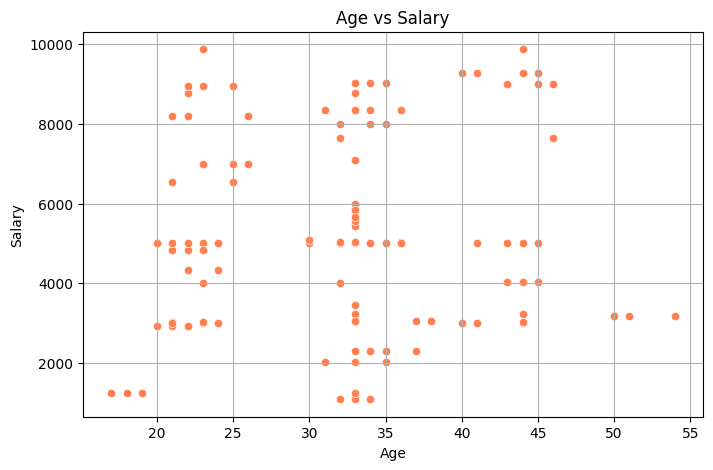

In [34]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(f"Number of rows matching filter: {len(filtered_df)}")

# 2. Plot Chart: Age vs Salary
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='salary', color='coral')
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

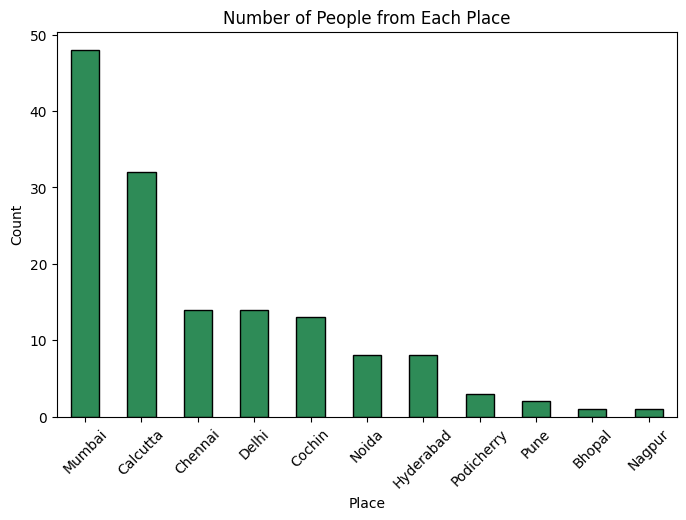

In [35]:
if 'place' in df.columns:
    plt.figure(figsize=(8, 5))
    df['place'].value_counts().plot(kind='bar', color='seagreen', edgecolor='black')
    plt.title('Number of People from Each Place')
    plt.xlabel('Place')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

DATA ENCODING

In [36]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", list(categorical_cols))

df_encoded = df.copy()

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

Categorical columns to encode: ['company', 'place', 'country']


FEATURE SCALING

In [39]:
features_to_scale = df_encoded.select_dtypes(include=[np.number]).columns
scaler_std = StandardScaler()
df_standard_scaled = df_encoded.copy()
df_standard_scaled[features_to_scale] = scaler_std.fit_transform(df_encoded[features_to_scale])
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df_encoded.copy()
df_minmax_scaled[features_to_scale] = scaler_minmax.fit_transform(df_encoded[features_to_scale])
print("\nData Preprocessing Completed!")
print("Standard Scaled version:")
print(df_standard_scaled.head(2))


Data Preprocessing Completed!
Standard Scaled version:
        age    salary    gender  company_Congnizant  company_Infosys  \
0 -1.484676 -0.100827 -0.534522               False            False   
1 -0.267174 -0.100827 -0.534522               False             True   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                    False         True                              False   
1                    False        False                              False   

   place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  \
0           False           True         False        False            False   
1           False          False         False        False            False   

   place_Mumbai  place_Nagpur  place_Noida  place_Podicherry  place_Pune  
0         False         False        False             False       False  
1          True         False        False             False       False  
